# 🧠 Layer Nodal Graph Metrics Summary & 3D Visualization – HCB & Naples

This code performs the following steps:

---

## 1. 📂 Load Nodal Graph Metrics (Excel)

It loads nodal graph metrics per subject and layer (`FA`, `GM` & `rsfMRI`) for both **HCB** and **Naples** cohorts from `.xlsx` files.

Each file contains values like:
- `degree`
- `strength`
- `betweenness`
- `closeness`
- `eigenvector`

A new column `Layer` is added to tag the network layer.

---

## 2. 🧾 Load Clinical Metadata

It loads `.csv` clinical files for HCB and Naples cohorts:
- Maps subject ID to `Subject`
- Converts numeric group label into `Group`: `Control` or `EM`

---

## 3. 🔁 Merge Nodal Metrics with Group Info

The nodal graph metrics are merged with clinical group labels using `Subject` ID as key. This enables grouping and comparisons.

---

## 4. 📊 Group-Level Summary by Node, Layer & Group

For each combination of:
- `Node` (brain region)
- `Group` (Control/EM)
- `Layer` (FA, GM, ...)

The code computes **mean** and **standard deviation** of all nodal metrics.

It outputs:
- A tidy long-format DataFrame `summary_long_hcb` and `summary_long_naples`
- Also saves it as `.csv` files for later use.

---

## 5. 🧠 Interactive 3D Brain Plot (Nilearn)

- Loads MNI coordinates of the 76 brain regions from a `.node` file.
- Selects a nodal metric (e.g. `'Degree_mean'`) to visualize.
- Selects a layer (`'FA'`, `'GM'`, ...) and group (`'Control'`, `'EM'`).
- Normalizes the metric values to `[0, 1]`.
- Maps values to a color scale (`viridis`).
- Generates an interactive **3D brain map** using `nilearn.plotting.view_markers()`.

This shows brain nodes color-coded by metric intensity.

---

## ✅ Output

- CSV summaries with nodal statistics
- Interactive HTML-based 3D visualization per group/layer/metric


In [1]:
import pandas as pd
import os

# ----------------------------------
# File paths configuration
# ----------------------------------
nodal_paths_hcb = {
    "FA": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/graph-metrics_FA_matrices_median_re/nodal_graph_metrics_FA.xlsx",
    "GM": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/graph-metrics_GM_matrices_median_re/nodal_graph_metrics_GM.xlsx",
    "rsfMRI": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/graph-metrics_rsfMRI_matrices_median_re/nodal_graph_metrics_rsfMRI.xlsx",
}

nodal_paths_naples = {
    "FA": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/graph-metrics_FA_matrices_median_re/nodal_graph_metrics_FA.xlsx",
    "GM": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/graph-metrics_GM_matrices_median_re/nodal_graph_metrics_GM.xlsx",
    "rsfMRI": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/graph-metrics_rsfMRI_matrices_median_re/nodal_graph_metrics_rsfMRI.xlsx",
}

# ----------------------------------
# Reusable functions
# ----------------------------------
def load_nodal_metrics(nodal_paths):
    """Load nodal graph metrics and tag with layer name."""
    dfs = [pd.read_excel(path).assign(Layer=layer) for layer, path in nodal_paths.items()]
    return pd.concat(dfs, ignore_index=True)

def load_clinic_df(path, id_col, group_col):
    """Load clinical data and map group labels (0=Control, 1=MS)."""
    df = pd.read_csv(path).rename(columns={id_col: "Subject"})
    df["Group"] = df[group_col].map({0: "Control", 1: "EM"})
    return df

def compute_nodal_summary(df):
    """Group nodal metrics by Node, Group and Layer; compute mean and std."""
    metrics = ["degree", "strength", "betweenness", "closeness", "eigenvector"]
    grouped = df.groupby(['Node', 'Group', 'Layer'])[metrics].agg(['mean', 'std']).reset_index()
    
    # Flatten column names
    grouped.columns = ['Node', 'Group', 'Layer'] + ['_'.join(col).capitalize() for col in grouped.columns[3:]]
    
    # Convert to long format
    long_df = pd.melt(grouped, id_vars=['Node', 'Group', 'Layer'], var_name='Metric', value_name='Value')
    return grouped, long_df

# ----------------------------------
# HCB cohort
# ----------------------------------
clinic_df_hcb = load_clinic_df("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/CLINIC_HCB_B.csv",
                                id_col="id", group_col="controls_ms"
)

df_nodal_hcb = load_nodal_metrics(nodal_paths_hcb)
df_merged_hcb = df_nodal_hcb.merge(clinic_df_hcb, on="Subject", how="inner")
summary_hcb, summary_long_hcb = compute_nodal_summary(df_merged_hcb)

# Save results
summary_long_hcb.to_csv("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/nodal_summary_by_group.csv",
                         index=False)
df_merged_hcb.to_csv("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/nodal_metrics_with_subjects.csv", 
                     index=False)

# ----------------------------------
# Naples cohort
# ----------------------------------
clinic_df_naples = load_clinic_df("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/CLINIC_NAPLES_B.csv",
                                  id_col="ID", group_col="GROUP")

df_nodal_naples = load_nodal_metrics(nodal_paths_naples)
df_merged_naples = df_nodal_naples.merge(clinic_df_naples, on="Subject", how="inner")
summary_naples, summary_long_naples = compute_nodal_summary(df_merged_naples)

# Save results
summary_long_naples.to_csv("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_layer/nodal_summary_by_group.csv",
                            index=False)
df_merged_naples.to_csv("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_layer/nodal_metrics_with_subjects.csv",
                         index=False)


### 📊 Ranking of Most Altered Brain Nodes Between Groups (Control − MS)

This section defines and runs a function that identifies the **top-n most altered brain nodes** for each **graph metric** and **connectivity layer**, based on group differences between **controls** and **MS patients**, for both the **HCB** and **Naples** cohorts.

#### 🔍 What it does:
1. **Transforms the data** from long to wide format, so each node has separate values for Control and MS groups.
2. **Calculates the difference** between groups (`Delta = Control − EM`) and its absolute value (`Abs_Delta`).
3. **Ranks nodes** within each combination of layer and metric by their absolute group difference.
4. **Selects the top N nodes** (default = 10) per layer and metric.
5. **Exports** the rankings to a `.csv` file for each cohort.

This helps highlight brain regions with the largest between-group differences in nodal graph metrics.


In [2]:
# ----------------------------------
# Define function to rank nodes and save results
# ----------------------------------
def compute_and_save_rankings(df_long, cohort_name, output_path, top_n=10):
    """
    Compute top-n nodal differences per metric/layer for one cohort and save to CSV.

    Parameters:
    - df_long: long-format DataFrame with columns ["Node", "Layer", "Metric", "Group", "Value"]
    - cohort_name: name of the cohort ("HCB" or "Naples")
    - output_path: full path to save the output CSV file
    - top_n: number of top nodes to keep per metric and layer
    """
    
    # Step 1: Pivot table to wide format with separate columns for Control and EM
    df_wide = df_long.pivot_table(
        index=["Node", "Layer", "Metric"], 
        columns="Group", 
        values="Value"
    ).reset_index()

    # Step 2: Compute Delta and its absolute value
    df_wide["Delta"] = df_wide["Control"] - df_wide["EM"]
    df_wide["Abs_Delta"] = df_wide["Delta"].abs()
    df_wide["Cohort"] = cohort_name  # Add cohort label

    # Step 3: Sort and select top N nodes per Layer and Metric by absolute delta
    ranked = (
        df_wide
        .sort_values(["Layer", "Metric", "Abs_Delta"], ascending=[True, True, False])
        .groupby(["Layer", "Metric"])
        .head(top_n)  # Keep top-n rows per group
        .copy()
    )

    # Step 4: Save to CSV
    ranked.to_csv(output_path, index=False)
    print(f"[✔] Saved ranking for {cohort_name} → {output_path}")

    return ranked  # Return the DataFrame for further use

# ----------------------------------
# Run for HCB
# ----------------------------------
ranked_hcb = compute_and_save_rankings(
    df_long=summary_long_hcb[summary_long_hcb["Metric"].str.endswith("_mean")],
    cohort_name="HCB",
    output_path="F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/"
                "DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/nodal_rankings_by_delta.csv",
    top_n=10
)

# ----------------------------------
# Run for Naples
# ----------------------------------
ranked_naples = compute_and_save_rankings(
    df_long=summary_long_naples[summary_long_naples["Metric"].str.endswith("_mean")],
    cohort_name="Naples",
    output_path="F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/"
                "DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_layer/nodal_rankings_by_delta.csv",
    top_n=10
)


[✔] Saved ranking for HCB → F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/nodal_rankings_by_delta.csv
[✔] Saved ranking for Naples → F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_layer/nodal_rankings_by_delta.csv


In [3]:
# ----------------------------------------
# Function to generate interpretation summary
# ----------------------------------------
def summarize_ranked_table(ranked_df, cohort_label):
    """Create a summary of nodal differences per layer and metric with interpretation."""
    summary = ranked_df.copy()

    # Add interpretation column based on Delta sign
    def interpret(row):
        if row["Delta"] > 0:
            return "↑ in controls"
        elif row["Delta"] < 0:
            return "↓ in MS"
        else:
            return "No change"

    summary["Interpretation"] = summary.apply(interpret, axis=1)
    summary["Cohort"] = cohort_label

    # Keep only relevant columns
    return summary[["Cohort", "Layer", "Metric", "Node", "Control", "EM", "Delta", "Interpretation"]]

# ----------------------------------------
# Apply function to both cohorts
# ----------------------------------------
summary_hcb = summarize_ranked_table(ranked_hcb, "HCB")
summary_naples = summarize_ranked_table(ranked_naples, "Naples")

# Combine both summaries
summary_combined = pd.concat([summary_hcb, summary_naples], ignore_index=True)

# ----------------------------------------
# Display preview
# ----------------------------------------
print(summary_hcb.head(5))  # Show first rows
print(summary_naples.head(5))  # Show first rows

# ----------------------------------------
# Save to CSV
# ----------------------------------------
output_path_hcb= "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/nodal_ranked_summary_interpretation.csv"
summary_hcb.to_csv (output_path_hcb, index=False) 
print(f"[✔] Saved ranking interpretation for HCB → {output_path_hcb}")

output_path_naples= "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_layer/nodal_ranked_summary_interpretation.csv"
summary_naples.to_csv (output_path_naples, index=False)  
print(f"[✔] Saved ranking interpretation for Naples → {output_path_naples}")

Group Cohort Layer            Metric  Node   Control        EM     Delta  \
840      HCB    FA  Betweenness_mean    56  0.058478  0.034823  0.023655   
150      HCB    FA  Betweenness_mean    10  0.005385  0.016880 -0.011494   
645      HCB    FA  Betweenness_mean    43  0.033393  0.021987  0.011406   
600      HCB    FA  Betweenness_mean    40  0.034915  0.024805  0.010110   
750      HCB    FA  Betweenness_mean    50  0.003624  0.013512 -0.009889   

Group Interpretation  
840    ↑ in controls  
150          ↓ in MS  
645    ↑ in controls  
600    ↑ in controls  
750          ↓ in MS  
Group  Cohort Layer            Metric  Node   Control        EM     Delta  \
540    Naples    FA  Betweenness_mean    36  0.047520  0.018884  0.028636   
555    Naples    FA  Betweenness_mean    37  0.079653  0.054775  0.024878   
645    Naples    FA  Betweenness_mean    43  0.049125  0.027963  0.021162   
630    Naples    FA  Betweenness_mean    42  0.026660  0.044103 -0.017443   
660    Naples    FA 

### 🔎 Interpretation of Betweenness Centrality Differences in FA Layer (HCB and Naples Cohorts)

This table presents the **top-ranked brain regions (nodes)** showing the greatest differences in a specific **graph metric** between **control subjects** and individuals with **multiple sclerosis (MS)**, across cohorts and connectivity layers.

#### 🧠 What each column means:

- **Cohort**: The study group (e.g., `HCB`, `Naples`).
- **Layer**: The type of connectivity layer analyzed (e.g., `FA`, `GM`, `rsfMRI`).
- **Metric**: The graph theory metric analyzed (e.g., `Betweenness_mean`, `Degree_mean`).
- **Node**: The ID of the brain region.
- **Control**: The average metric value for the control group.
- **EM**: The average metric value for the MS group (`EM` = Esclerosis Múltiple).
- **Delta**: The difference in metric values between groups (`Delta = Control − EM`).
- **Interpretation**: A quick summary of which group shows higher values:
  - `"↑ in controls"` → The node has a higher value in **controls**
  - `"↓ in MS"` → The node has a higher value in **MS patients**

#### 🔍 How to use this:

- Use this table to **identify the most affected brain regions** in MS.
- Focus on nodes with **large absolute delta values** — they represent the strongest group differences.
- Map these nodes to anatomical regions using the node index and an atlas (e.g., Mindboggle).

The table above summarizes the top-ranked nodes with the greatest differences in **betweenness centrality** within the **FA (structural connectivity)** layer for both the **HCB** and **Naples** cohorts. 

In the **HCB cohort**, several nodes (e.g., nodes 56, 43, 40) show higher betweenness in the **control group** compared to patients with multiple sclerosis (MS), indicating that these regions may play a more central role in network communication in healthy individuals. Conversely, nodes such as 10 and 50 show increased betweenness in **MS subjects**, suggesting a potential compensatory mechanism or network reorganization.

Similarly, in the **Naples cohort**, nodes like 36, 37, 43, and 44 exhibit greater centrality in **controls**, reinforcing the idea of disrupted hub-like roles in MS. Interestingly, node 42 displays higher betweenness in **MS patients**, possibly reflecting localized alterations in structural routing within the brain network.

These patterns highlight specific brain regions where MS may affect structural integration, and they serve as candidate regions for further anatomical or clinical correlation.


### 🧠 3D Brain Visualization of Nodal Differences

This section of the notebook generates interactive 3D brain visualizations showing the top 10 nodes with the greatest differences in graph metrics (e.g., betweenness) between controls and MS patients. For each cohort (HCB, Naples), connectivity layer (FA, GM, rsfMRI), and metric, the top-ranked nodes are highlighted using a color gradient (red = higher in controls, blue = higher in MS). 

Node positions are based on MNI coordinates, and each visualization is saved as an HTML file for easy inspection and integration into reports or presentations.


In [4]:
from nilearn import plotting
from sklearn.preprocessing import MinMaxScaler
from matplotlib import cm

# ----------------------------------------
# Load node coordinates (.node format)
# ----------------------------------------
coords_df = pd.read_csv(
    "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/Node_mindboggle_default.node",
    sep="\t", header=None
)
coords_df.columns = ["X", "Y", "Z", "Node", "Hemisphere", "Region"]
coords_df = coords_df.sort_values("Node").reset_index(drop=True)

# ----------------------------------------
# Prepare combined ranked DataFrame
# ----------------------------------------
ranked_hcb["Cohort"] = "HCB"
ranked_naples["Cohort"] = "Naples"
ranked_all = pd.concat([ranked_hcb, ranked_naples], ignore_index=True)

# ----------------------------------------
# Loop through combinations
# ----------------------------------------
views = []  # Store all generated 3D views

for cohort in ["HCB", "Naples"]:
    cohort_df = ranked_all[ranked_all["Cohort"] == cohort]  # Filter by cohort
    for layer in cohort_df["Layer"].unique():  # Loop through connectivity layers (FA, GM, etc.)
        for metric in cohort_df["Metric"].unique():  # Loop through nodal graph metrics
            # Get top 10 nodes with largest absolute Delta values
            subset = cohort_df[
                (cohort_df["Layer"] == layer) & (cohort_df["Metric"] == metric)
            ].sort_values("Abs_Delta", ascending=False).head(10)

            if subset.empty:
                continue  # Skip if no data available

            # Retrieve node coordinates (adjusting for 0-based indexing)
            node_ids = subset["Node"].astype(int).values - 1
            node_coords = coords_df.iloc[node_ids][["X", "Y", "Z"]].values
            node_labels = coords_df.iloc[node_ids]["Region"].values.tolist()         

            # Normalize Delta values between 0 and 1 for color mapping
            norm_values = MinMaxScaler().fit_transform(subset["Delta"].values.reshape(-1, 1)).flatten()
            colors = cm.get_cmap("coolwarm")(norm_values)  # Red = higher in controls, blue = higher in MS         
            
            
            # Create 3D brain visualization using Nilearn
            view = plotting.view_markers(
                node_coords,
                marker_color=colors,
                  marker_labels=node_labels, 
                marker_size=6,
                title=f"{cohort} | {layer} | {metric}\n(Δ = Control − EM, Red:↑C, Blue:↑MS)"
            )

            # Console feedback
            print(f"🧠 View ready: Cohort = {cohort} | Layer = {layer} | Metric = {metric}")

            # Store view for saving
            views.append((cohort, layer, metric, view))

            # Automatically open the first view in browser (optional)
            if len(views) == 1:
                view.open_in_browser()

# Output directories for HTML files 
output_dir_hcb_3d = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/figures/3D"
output_dir_naples_3d = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_layer/figures/3D"

# Create directories if they do not exist
os.makedirs(output_dir_hcb_3d, exist_ok=True)
os.makedirs(output_dir_naples_3d, exist_ok=True)

# Save each view as HTML
for cohort, layer, metric, view in views:
    filename = f"{cohort}_{layer}_{metric.replace('/', '_')}_3D.html"
    save_path = os.path.join(output_dir_hcb_3d if cohort == "HCB" else output_dir_naples_3d, filename)
    view.save_as_html(save_path)
    print(f"✅ Saved: {save_path}")

C:\Users\alvar\AppData\Local\Temp\ipykernel_18744\1460558130.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)  # Red = higher in controls, blue = higher in MS


🧠 View ready: Cohort = HCB | Layer = FA | Metric = Betweenness_mean


C:\Users\alvar\AppData\Local\Temp\ipykernel_18744\1460558130.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)  # Red = higher in controls, blue = higher in MS
C:\Users\alvar\AppData\Local\Temp\ipykernel_18744\1460558130.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)  # Red = higher in controls, blue = higher in MS
C:\Users\alvar\AppData\Local\Temp\ipykernel_18744\1460558130.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or

🧠 View ready: Cohort = HCB | Layer = FA | Metric = Closeness_mean
🧠 View ready: Cohort = HCB | Layer = FA | Metric = Degree_mean
🧠 View ready: Cohort = HCB | Layer = FA | Metric = Eigenvector_mean
🧠 View ready: Cohort = HCB | Layer = FA | Metric = Strength_mean
🧠 View ready: Cohort = HCB | Layer = GM | Metric = Betweenness_mean
🧠 View ready: Cohort = HCB | Layer = GM | Metric = Closeness_mean
🧠 View ready: Cohort = HCB | Layer = GM | Metric = Degree_mean


C:\Users\alvar\AppData\Local\Temp\ipykernel_18744\1460558130.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)  # Red = higher in controls, blue = higher in MS
C:\Users\alvar\AppData\Local\Temp\ipykernel_18744\1460558130.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)  # Red = higher in controls, blue = higher in MS
f:\Cursos\UOC Master Bio Inf. Est\M0.209 - UOC - TFM - Bio ML - Grafos\venv\Lib\site-packages\nilearn\plotting\html_document.py:103: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabyte

...

🧠 View ready: Cohort = HCB | Layer = rsfMRI | Metric = Strength_mean
🧠 View ready: Cohort = Naples | Layer = FA | Metric = Betweenness_mean
🧠 View ready: Cohort = Naples | Layer = FA | Metric = Closeness_mean
🧠 View ready: Cohort = Naples | Layer = FA | Metric = Degree_mean
🧠 View ready: Cohort = Naples | Layer = FA | Metric = Eigenvector_mean
🧠 View ready: Cohort = Naples | Layer = FA | Metric = Strength_mean
🧠 View ready: Cohort = Naples | Layer = GM | Metric = Betweenness_mean


f:\Cursos\UOC Master Bio Inf. Est\M0.209 - UOC - TFM - Bio ML - Grafos\venv\Lib\site-packages\nilearn\plotting\html_document.py:103: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn(
C:\Users\alvar\AppData\Local\Temp\ipykernel_18744\1460558130.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)  # Red = higher in controls, blue = higher in MS
f:\Cursos\UOC Master Bio Inf. Est\M0.209 - UOC - TFM - Bio ML - Grafos\venv\Lib\site-packages\nilearn\plotting\html_document.py:103: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn(
C:\Users\alvar

🧠 View ready: Cohort = Naples | Layer = GM | Metric = Closeness_mean
🧠 View ready: Cohort = Naples | Layer = GM | Metric = Degree_mean
🧠 View ready: Cohort = Naples | Layer = GM | Metric = Eigenvector_mean
🧠 View ready: Cohort = Naples | Layer = GM | Metric = Strength_mean
🧠 View ready: Cohort = Naples | Layer = rsfMRI | Metric = Betweenness_mean
🧠 View ready: Cohort = Naples | Layer = rsfMRI | Metric = Closeness_mean
🧠 View ready: Cohort = Naples | Layer = rsfMRI | Metric = Degree_mean


f:\Cursos\UOC Master Bio Inf. Est\M0.209 - UOC - TFM - Bio ML - Grafos\venv\Lib\site-packages\nilearn\plotting\html_document.py:103: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn(
C:\Users\alvar\AppData\Local\Temp\ipykernel_18744\1460558130.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)  # Red = higher in controls, blue = higher in MS
f:\Cursos\UOC Master Bio Inf. Est\M0.209 - UOC - TFM - Bio ML - Grafos\venv\Lib\site-packages\nilearn\plotting\html_document.py:103: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn(
C:\Users\alvar

🧠 View ready: Cohort = Naples | Layer = rsfMRI | Metric = Eigenvector_mean
🧠 View ready: Cohort = Naples | Layer = rsfMRI | Metric = Strength_mean
✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/figures/3D\HCB_FA_Betweenness_mean_3D.html
✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/figures/3D\HCB_FA_Closeness_mean_3D.html
✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/figures/3D\HCB_FA_Degree_mean_3D.html
✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/figures/3D\HCB_FA_Eigenvector_mean_3D.html
✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nod

### 🧠 2D Top View: Most Altered Brain Nodes by Graph Metric

This section generates **2D top-view plots** of the top 10 most altered brain nodes in each cohort, layer, and nodal graph metric. Specifically:

- For each combination of **cohort** (`HCB`, `Naples`), **connectivity layer** (`FA`, `GM`, `rsfMRI`), and **metric** (e.g., `Degree_mean`), the top 10 nodes with the largest absolute group difference (`|Δ| = Control − MS`) are selected.
- Nodes are plotted in **axial view** using their MNI coordinates, with a color gradient indicating the direction of group difference:  
  **Red** = higher in controls, **Blue** = higher in MS.
- No edges are shown (empty adjacency matrix) to focus solely on node-level alterations.
- Each plot is saved as a `.png` image for both HCB and Naples cohorts.

These figures help identify spatial patterns of brain network disruption associated with multiple sclerosis, and are suitable for inclusion in presentations and reports.


C:\Users\alvar\AppData\Local\Temp\ipykernel_18744\601277930.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)  # Red = ↑ Control, Blue = ↑ MS


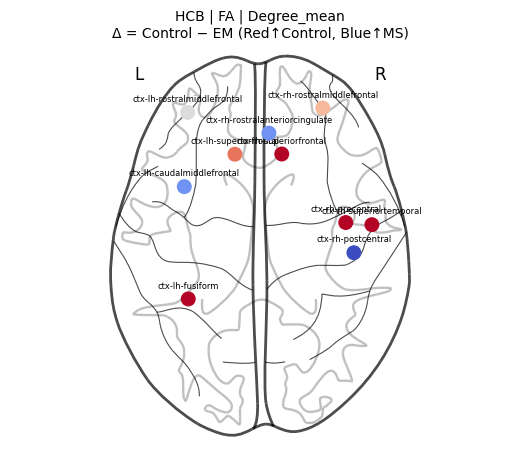

C:\Users\alvar\AppData\Local\Temp\ipykernel_18744\601277930.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C:\Users\alvar\AppData\Local\Temp\ipykernel_18744\601277930.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C:\Users\alvar\AppData\Local\Temp\ipykernel_18744\601277930.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C:\U

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Top 10 most altered nodes in HCB | FA | Degree_mean
subset = ranked_hcb[
    (ranked_hcb["Layer"] == "FA") &
    (ranked_hcb["Metric"] == "Degree_mean")
].sort_values("Abs_Delta", ascending=False).head(10)

# Get coordinates of the selected nodes
node_ids = subset["Node"].astype(int).values - 1  # Adjust to 0-based indexing
node_coords = coords_df.iloc[node_ids][["X", "Y", "Z"]].values
delta_values = subset["Delta"].values

# Normalize Delta values for coloring
norm_values = MinMaxScaler().fit_transform(delta_values.reshape(-1, 1)).flatten()
colors = cm.get_cmap("coolwarm")(norm_values)  # Red = ↑ Control, Blue = ↑ MS

# Create an empty adjacency matrix (no edges to display)
adjacency = np.zeros((len(node_coords), len(node_coords)))

# Set figure size
fig = plt.figure(figsize=(5, 4))

# Plot top-view of nodes (axial/z-axis view)
display = plotting.plot_connectome(
    adjacency_matrix=adjacency,
    node_coords=node_coords,
    node_color=colors,
    node_size=95,
    display_mode='z',
    figure=fig,
)

# Add node labels using correct axis
node_labels = coords_df.iloc[node_ids]["Region"].values.tolist()
ax = plt.gca()
for (x, y, label) in zip(node_coords[:, 0], node_coords[:, 1], node_labels):
    ax.text(x, y + 4, label, fontsize=6, ha='center', va='bottom', color='black')

# Manually set title with smaller font size
plt.title("HCB | FA | Degree_mean\nΔ = Control − EM (Red↑Control, Blue↑MS)", fontsize=10)
plt.show()

# Define output directories for 2D plots
output_dir_hcb_2d = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/figures/2D"
output_dir_naples_2d = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_layer/figures/2D"

# Create directories if they don't exist
os.makedirs(output_dir_hcb_2d, exist_ok=True)
os.makedirs(output_dir_naples_2d, exist_ok=True)

# Function to generate and save top-view 2D plots for each cohort/layer/metric
def save_topview_2d(df, cohort, output_dir):
    for layer in df["Layer"].unique():
        for metric in df["Metric"].unique():
            subset = df[
                (df["Layer"] == layer) &
                (df["Metric"] == metric)
            ].sort_values("Abs_Delta", ascending=False).head(10)

            if subset.empty:
                continue

            node_ids = subset["Node"].astype(int).values - 1
            node_coords = coords_df.iloc[node_ids][["X", "Y", "Z"]].values
            norm_values = MinMaxScaler().fit_transform(subset["Delta"].values.reshape(-1, 1)).flatten()
            colors = cm.get_cmap("coolwarm")(norm_values)
            adjacency = np.zeros((len(node_coords), len(node_coords)))

            fig = plt.figure(figsize=(5, 4))
            plotting.plot_connectome(
                adjacency_matrix=adjacency,
                node_coords=node_coords,
                node_color=colors,
                node_size=95,
                display_mode='z',
                figure=fig,
            )
            # Add node labels manually
            node_labels = coords_df.iloc[node_ids]["Region"].values.tolist()
            ax = plt.gca()
            for (x, y, label) in zip(node_coords[:, 0], node_coords[:, 1], node_labels):
                ax.text(x, y + 4, label, fontsize=6, ha='center', va='bottom', color='black')

            plt.title(f"{cohort} | {layer} | {metric}\nΔ = Control − EM", fontsize=10)

            filename = f"{cohort}_{layer}_{metric.replace('/', '_')}_topview.png"
            plt.savefig(os.path.join(output_dir, filename), bbox_inches='tight')
            plt.close()

# Generate and save plots for both cohorts
save_topview_2d(ranked_hcb, "HCB", output_dir_hcb_2d)
save_topview_2d(ranked_naples, "Naples", output_dir_naples_2d)

### 🔄 Delta Computation and 2D Visualization of Nodal Differences (All nodes)

This section performs a full pipeline to compute and visualize group-level differences in nodal graph metrics:

1. **Compute Δ (Control − MS):**  
   For each node, metric, and layer, the mean difference between the control group and MS patients is calculated and stored as `Delta` (and `Abs_Delta` for ranking).

2. **Prepare Output Folders:**  
   Creates separate folders for HCB and Naples cohorts to store resulting 2D visualizations and data.

3. **Generate 2D Top-View Plots:**  
   For each cohort, connectivity layer, and metric:
   - Nodes are color-coded by Delta values (red = higher in controls, blue = higher in MS).
   - Nodes are displayed in axial (top) view with no edges.
   - One plot is generated per combination and saved as a PNG file.

4. **Export CSVs:**  
   Saves the computed Delta values into `.csv` files for further analysis or reporting.


In [6]:
# -------------------------------
# Compute delta (Control − EM)
# -------------------------------
def compute_delta_from_summary(summary_long, cohort_name):
    summary_mean = summary_long[summary_long["Metric"].str.endswith("_mean")].copy()
    pivot = summary_mean.pivot_table(index=["Node", "Layer", "Metric"], columns="Group", values="Value").reset_index()
    pivot["Delta"] = pivot["Control"] - pivot["EM"]
    pivot["Abs_Delta"] = pivot["Delta"].abs()
    pivot["Cohort"] = cohort_name
    return pivot

delta_hcb = compute_delta_from_summary(summary_long_hcb, "HCB")
delta_naples = compute_delta_from_summary(summary_long_naples, "Naples")
delta_all = pd.concat([delta_hcb, delta_naples], ignore_index=True)

# -------------------------------
# Set output folders
# -------------------------------
output_dir_hcb_delta_2d = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/figures/Delta_2D"
output_dir_naples_delta_2d = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_layer/figures/Delta_2D"

os.makedirs(output_dir_hcb_delta_2d, exist_ok=True)
os.makedirs(output_dir_naples_delta_2d, exist_ok=True)

# -------------------------------
# Step 3: Loop and generate plots
# -------------------------------
for cohort in ["HCB", "Naples"]:
    df = delta_all[delta_all["Cohort"] == cohort]
    output_dir = output_dir_hcb_delta_2d if cohort == "HCB" else output_dir_naples_delta_2d
    
    for layer in df["Layer"].unique():
        for metric in df["Metric"].unique():
            subset = df[
                (df["Layer"] == layer) &
                (df["Metric"] == metric)
            ]

            if subset.empty:
                continue

            node_ids = subset["Node"].astype(int).values - 1
            node_coords = coords_df.iloc[node_ids][["X", "Y", "Z"]].values
            node_labels = coords_df.iloc[node_ids]["Region"].values.tolist()
            norm_values = MinMaxScaler().fit_transform(subset["Delta"].values.reshape(-1, 1)).flatten()
            colors = cm.get_cmap("coolwarm")(norm_values)
            adjacency = np.zeros((len(node_coords), len(node_coords)))

            fig = plt.figure(figsize=(10, 8))
            plotting.plot_connectome(
                adjacency_matrix=adjacency,
                node_coords=node_coords,
                node_color=colors,
                node_size=120,
                display_mode='z',
                figure=fig,
            )
            ax = plt.gca()
            for (x, y, label) in zip(node_coords[:, 0], node_coords[:, 1], node_labels):
                ax.text(x, y + 4, label, fontsize=6, ha='center', va='bottom', color='black')

            plt.title(f"{cohort} | {layer} | {metric}\nΔ = Control − EM", fontsize=12)

            filename = f"{cohort}_{layer}_{metric.replace('/', '_')}_delta_topview.png"
            plt.savefig(os.path.join(output_dir, filename), bbox_inches='tight')
            plt.close()

# Export CSV: nodal deltas (Control − EM)
# Save the delta DataFrames to CSV

delta_hcb.to_csv(os.path.join(output_dir_hcb_delta_2d, "nodal_deltas_by_group.csv"), index=False)   
delta_naples.to_csv(os.path.join(output_dir_naples_delta_2d, "nodal_deltas_by_group.csv"), index=False)

print("✅ CSVs saved:")
print(f"- HCB → {output_dir_hcb_delta_2d}")
print(f"- Naples → {output_dir_naples_delta_2d}")

C:\Users\alvar\AppData\Local\Temp\ipykernel_18744\3386669322.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C:\Users\alvar\AppData\Local\Temp\ipykernel_18744\3386669322.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C:\Users\alvar\AppData\Local\Temp\ipykernel_18744\3386669322.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C

✅ CSVs saved:
- HCB → F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/figures/Delta_2D
- Naples → F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_layer/figures/Delta_2D


### 🧠 3D Interactive Visualization of Mean Nodal Differences (Delta) - All nodes

This section computes and visualizes the **mean group difference (Δ = Control − MS)** in nodal graph metrics across cohorts using **3D interactive plots**:

1. **Compute Delta (Control − MS):**  
   For each node, layer, and metric, the mean value in each group is used to calculate `Delta`. These results are stored per cohort (`HCB`, `Naples`).

2. **Generate 3D Views:**  
   For each combination of **cohort**, **connectivity layer**, and **graph metric**, an interactive brain view is created with:
   - Nodes plotted based on MNI coordinates.
   - Color-coded Δ values (Red = higher in controls, Blue = higher in MS).
   - No edges, focusing on node-level differences.

3. **Export as HTML:**  
   Each 3D visualization is saved as an `.html` file for easy navigation, sharing, or embedding into reports.

4. **Export CSVs:**  
   Delta values are also saved as `.csv` files for reference or additional analysis.

This pipeline provides an intuitive and interactive way to explore brain network alterations between control and MS groups at the nodal level.


In [7]:
# ----------------------------------------
# Compute mean deltas (Control − EM) per cohort
# ----------------------------------------
def compute_delta_for_3d(summary_long, cohort_name):
    df_mean = summary_long[summary_long["Metric"].str.endswith("_mean")].copy()
    pivot = df_mean.pivot_table(index=["Node", "Layer", "Metric"], columns="Group", values="Value").reset_index()
    pivot["Delta"] = pivot["Control"] - pivot["EM"]
    pivot["Cohort"] = cohort_name
    return pivot

# Compute delta for each cohort
delta_hcb_3d = compute_delta_for_3d(summary_long_hcb, "HCB")
delta_naples_3d = compute_delta_for_3d(summary_long_naples, "Naples")
delta_all_3d = pd.concat([delta_hcb_3d, delta_naples_3d], ignore_index=True)

# ----------------------------------------
# Create interactive 3D views
# ----------------------------------------
views_3d_deltas = []
for cohort in ["HCB", "Naples"]:
    df = delta_all_3d[delta_all_3d["Cohort"] == cohort]
    for layer in df["Layer"].unique():
        for metric in df["Metric"].unique():
            subset = df[
                (df["Layer"] == layer) & (df["Metric"] == metric)
            ]
            if subset.empty:
                continue

            node_ids = subset["Node"].astype(int).values - 1  # 0-based index
            node_coords = coords_df.iloc[node_ids][["X", "Y", "Z"]].values
            node_labels = coords_df.iloc[node_ids]["Region"].values.tolist()
            norm_values = MinMaxScaler().fit_transform(subset["Delta"].values.reshape(-1, 1)).flatten()
            colors = cm.get_cmap("coolwarm")(norm_values)  # Red = ↑ Control, Blue = ↑ MS

            # Create interactive 3D plot
            view = plotting.view_markers(
                node_coords,
                marker_color=colors,
                marker_size=6,
                marker_labels=node_labels,
                title=f"{cohort} | {layer} | {metric}\nΔ = Control − EM (Red↑Control, Blue↑MS)"
            )
            views_3d_deltas.append((cohort, layer, metric, view))

# Open the first 3D view in the browser
views_3d_deltas[0][3].open_in_browser()

# ----------------------------------------
# Output directories for HTML files
# ----------------------------------------
output_dir_hcb_3d_delta = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/figures/3D_DELTA"
output_dir_naples_3d_delta = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_layer/figures/3D_DELTA"

# Create folders if they don’t exist
os.makedirs(output_dir_hcb_3d_delta, exist_ok=True)
os.makedirs(output_dir_naples_3d_delta, exist_ok=True)

# ----------------------------------------
# Save each 3D view as HTML file
# ----------------------------------------
for cohort, layer, metric, view in views_3d_deltas:
    filename = f"{cohort}_{layer}_{metric.replace('/', '_')}_delta_3D.html"
    output_path = os.path.join(
        output_dir_hcb_3d_delta if cohort == "HCB" else output_dir_naples_3d_delta,
        filename
    )
    view.save_as_html(output_path)
    print(f"✅ Saved: {output_path}")

# ----------------------------------------
# Export CSV files: nodal deltas (Control − EM)
# ----------------------------------------
delta_hcb_3d.to_csv(os.path.join(output_dir_hcb_3d_delta, "nodal_deltas_by_group.csv"), index=False)   
delta_naples_3d.to_csv(os.path.join(output_dir_naples_3d_delta, "nodal_deltas_by_group.csv"), index=False)

print("✅ CSVs saved:")
print(f"- HCB → {output_dir_hcb_3d_delta}")
print(f"- Naples → {output_dir_naples_3d_delta}")

C:\Users\alvar\AppData\Local\Temp\ipykernel_18744\253272259.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)  # Red = ↑ Control, Blue = ↑ MS
f:\Cursos\UOC Master Bio Inf. Est\M0.209 - UOC - TFM - Bio ML - Grafos\venv\Lib\site-packages\nilearn\plotting\html_document.py:103: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn(
C:\Users\alvar\AppData\Local\Temp\ipykernel_18744\253272259.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)  #

✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/figures/3D_DELTA\HCB_FA_Betweenness_mean_delta_3D.html
✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/figures/3D_DELTA\HCB_FA_Closeness_mean_delta_3D.html
✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/figures/3D_DELTA\HCB_FA_Degree_mean_delta_3D.html
✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/figures/3D_DELTA\HCB_FA_Eigenvector_mean_delta_3D.html
✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_layer/figures/3D_DELTA\HCB_FA_Strength_mean_delta_3D.html
✅ Saved: F:/Cursos/UOC Master 